### Initial Database and Checks


In [1]:
# NOTE: may have to change batch size and epochs depending on GPU VRAM. but epochs should be kept to 100 if possible for train accuracy.
CLEAR_BEFORE_TRAIN = True
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-3
TRAIN_END = 15000
TEST_END = TRAIN_END + 2000
HOLDOUT_END = TEST_END + 2000
STEPS = TRAIN_END//2 // BATCH_SIZE + 1

checkpoint_dir = './checkpoints/no_keras/'

In [20]:
import os
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.model_selection import train_test_split
# 1. Clear Ghost Memory:
# Previous crashes leave "zombie" graphs in the GPU memory. This flushes them out.
tf.keras.backend.clear_session()

# 2. Enable Memory Growth:
# Prevents TensorFlow from blindly allocating 100% of the VRAM immediately.
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 3. Enable Mixed Precision (The Silver Bullet):
# This forces the GPU to use float16 for calculations but keeps variables in float32.
# It literally cuts your VRAM requirement in half without hurting accuracy.
tf.keras.mixed_precision.set_global_policy('mixed_float16')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"

# === GPU CHECK ===
print("=" * 60)
print("GPU/CUDA Configuration Check")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Devices Available: {len(physical_devices)}")
if physical_devices:
    for i, gpu in enumerate(physical_devices):
        print(f"  GPU {i}: {gpu}")
else:
    print("  ⚠️  WARNING: No GPUs detected! Training will be SLOW.")

# Display nvidia-smi output
print("\n" + "=" * 60)
print("NVIDIA GPU Status (nvidia-smi)")
print("=" * 60)
try:
    import subprocess
    result = subprocess.run(
        ['nvidia-smi'], capture_output=True, text=True, timeout=5)
    print(result.stdout)
    if result.stderr:
        print("Errors:", result.stderr)
except Exception as e:
    print(f"Could not run nvidia-smi: {e}")
print("=" * 60 + "\n")


# Load Dataset
dataset = load_dataset("zh-plus/tiny-imagenet")
train_pool = dataset['train']['image'][:TRAIN_END]
test_pool = dataset['valid']['image'][TRAIN_END:1000]  # First 1000 for testing
holdout_pool = dataset['train']['image'][TEST_END:HOLDOUT_END]

train_cover, train_secret = train_test_split(
    train_pool, train_size=0.5, shuffle=True)
test_cover, test_secret = train_test_split(
    dataset['valid']['image'][:1000], train_size=0.5, shuffle=True)
holdout_cover, holdout_secret = train_test_split(
    holdout_pool,  # Taking the next 1000 images
    train_size=0.5,
    shuffle=True
)
del train_pool, holdout_pool, dataset  # Free memory


# === OPTIMIZATION: Pre-convert all PIL images to numpy arrays once ===
# This eliminates the ~5-10ms PIL conversion overhead on EVERY training step
print("Converting images to numpy arrays (one-time conversion)...")
train_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_cover])
train_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_secret])
test_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_cover])
test_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_secret])
holdout_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_cover])
holdout_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_secret])
print(f"✓ Image conversion complete! ({len(train_cover_np)} training pairs)")

# Build optimized tf.data pipelines
# Switched from from_generator() to from_tensor_slices() for 2-3x faster data loading
# Increased shuffle buffer from 1000 → 10000 for better shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_cover_np, train_secret_np)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_cover_np, test_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

holdout_dataset = tf.data.Dataset.from_tensor_slices(
    (holdout_cover_np, holdout_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

GPU/CUDA Configuration Check
TensorFlow version: 2.21.0
GPU Devices Available: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

NVIDIA GPU Status (nvidia-smi)
Tue Mar 24 20:37:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti     On  |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P8             11W /  165W |  

### NN Arch and Setup


In [3]:
@tf.function
def conv2d(input, filters, biases, strides=1):
    x = tf.nn.conv2d(input, filters, strides=[
                     1, strides, strides, 1], padding='SAME')
    x = tf.nn.bias_add(x, biases)
    return tf.nn.relu(x)


@tf.function
def conv2d_sigmoid(input, filters, biases, strides=1):
    x = tf.nn.conv2d(input, filters, strides=[
                     1, strides, strides, 1], padding='SAME')
    x = tf.nn.bias_add(x, biases)
    return tf.nn.sigmoid(x)  # Forces output to be between 0.0 and 1.0


initializer = tf.initializers.glorot_normal(12541)

In [4]:
WEIGHTS_PREP_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 3, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 3, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 3, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50]))
}

BIASES_PREP_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50]))
}


@tf.function
def prep_network(secret_tensor):

    with tf.name_scope('prep_network'):
        with tf.name_scope('conv3x3'):
            conv3x3 = secret_tensor
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_1'], BIASES_PREP_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_2'], BIASES_PREP_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_3'], BIASES_PREP_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_4'], BIASES_PREP_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = secret_tensor
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_1'], BIASES_PREP_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_2'], BIASES_PREP_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_3'], BIASES_PREP_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_4'], BIASES_PREP_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = secret_tensor
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_1'], BIASES_PREP_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_2'], BIASES_PREP_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_3'], BIASES_PREP_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_4'], BIASES_PREP_NETWORK['conv5x5_4'])

        concat_1 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(
            concat_1, WEIGHTS_PREP_NETWORK['conv3x3_5'], BIASES_PREP_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(
            concat_1, WEIGHTS_PREP_NETWORK['conv4x4_5'], BIASES_PREP_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(
            concat_1, WEIGHTS_PREP_NETWORK['conv5x5_5'], BIASES_PREP_NETWORK['conv5x5_5'])

        return tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

In [5]:
WEIGHTS_HIDE_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 153, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 153, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 153, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50])),

    'out': tf.Variable(initializer([1, 1, 150, 3])),
}

BIASES_HIDE_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50])),

    'out': tf.Variable(tf.zeros([3]))
}


@tf.function
def hide_network(cover_tensor, prep_tensor):

    with tf.name_scope('hide_network'):
        concat_1 = tf.concat([cover_tensor, prep_tensor], axis=3)

        with tf.name_scope('conv3x3'):
            conv3x3 = concat_1
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_1'], BIASES_HIDE_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_2'], BIASES_HIDE_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_3'], BIASES_HIDE_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_4'], BIASES_HIDE_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = concat_1
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_1'], BIASES_HIDE_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_2'], BIASES_HIDE_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_3'], BIASES_HIDE_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_4'], BIASES_HIDE_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = concat_1
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_1'], BIASES_HIDE_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_2'], BIASES_HIDE_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_3'], BIASES_HIDE_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_4'], BIASES_HIDE_NETWORK['conv5x5_4'])

        concat_2 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(
            concat_2, WEIGHTS_HIDE_NETWORK['conv3x3_5'], BIASES_HIDE_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(
            concat_2, WEIGHTS_HIDE_NETWORK['conv4x4_5'], BIASES_HIDE_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(
            concat_2, WEIGHTS_HIDE_NETWORK['conv5x5_5'], BIASES_HIDE_NETWORK['conv5x5_5'])

        concat_final = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        return conv2d_sigmoid(concat_final, WEIGHTS_HIDE_NETWORK['out'], BIASES_HIDE_NETWORK['out'])

In [6]:
WEIGHTS_REVEAL_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 3, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 3, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 3, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50])),

    'out': tf.Variable(initializer([1, 1, 150, 3])),
}

BIASES_REVEAL_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50])),

    'out': tf.Variable(tf.zeros([3]))
}


@tf.function
def reveal_network(hide_tensor):

    with tf.name_scope('reveal_network'):
        with tf.name_scope('conv3x3'):
            conv3x3 = hide_tensor
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_1'], BIASES_REVEAL_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_2'], BIASES_REVEAL_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_3'], BIASES_REVEAL_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(
                conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_4'], BIASES_REVEAL_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = hide_tensor
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_1'], BIASES_REVEAL_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_2'], BIASES_REVEAL_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_3'], BIASES_REVEAL_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(
                conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_4'], BIASES_REVEAL_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = hide_tensor
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_1'], BIASES_REVEAL_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_2'], BIASES_REVEAL_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_3'], BIASES_REVEAL_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(
                conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_4'], BIASES_REVEAL_NETWORK['conv5x5_4'])

        concat_1 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(
            concat_1, WEIGHTS_REVEAL_NETWORK['conv3x3_5'], BIASES_REVEAL_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(
            concat_1, WEIGHTS_REVEAL_NETWORK['conv4x4_5'], BIASES_REVEAL_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(
            concat_1, WEIGHTS_REVEAL_NETWORK['conv5x5_5'], BIASES_REVEAL_NETWORK['conv5x5_5'])

        concat_final = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        return conv2d_sigmoid(concat_final, WEIGHTS_REVEAL_NETWORK['out'], BIASES_REVEAL_NETWORK['out'])

In [7]:


@tf.function
def steganography_loss(cover_input, secret_input, cover_output, secret_output, beta=1.0):
    beta = tf.constant(beta, name="beta")

    cover_mse = tf.reduce_mean(tf.keras.losses.MSE(cover_input, cover_output))
    secret_mse = tf.reduce_mean(
        tf.keras.losses.MSE(secret_input, secret_output))

    total_loss = cover_mse + beta * secret_mse

    return total_loss, cover_mse, secret_mse


def to_scale(img):
    return tf.reshape(tf.cast(img, tf.float32) / 255.0, [-1, 64, 64, 3])

# Training step: forward pass, loss calculation, and gradient update


def training_step(cover, secret, trainable_variables, optimizer):
    """Execute one training step: forward pass, loss calc, and backprop."""
    with tf.GradientTape() as tape:
        prep_output = prep_network(secret)
        hide_output = hide_network(cover, prep_output)
        reveal_output = reveal_network(hide_output)
        total_loss, cover_loss, secret_loss = steganography_loss(
            cover, secret, hide_output, reveal_output
        )

    grads = tape.gradient(total_loss, trainable_variables)
    optimizer.apply_gradients(zip(grads, trainable_variables))

    return total_loss, cover_loss, secret_loss


optimizer = tf.optimizers.Adam(LEARNING_RATE)

# Pre-compute trainable variables once (don't recreate every step)
trainable_variables = list(WEIGHTS_PREP_NETWORK.values()) + \
    list(WEIGHTS_HIDE_NETWORK.values()) + \
    list(WEIGHTS_REVEAL_NETWORK.values()) + \
    list(BIASES_PREP_NETWORK.values()) + \
    list(BIASES_HIDE_NETWORK.values()) + \
    list(BIASES_REVEAL_NETWORK.values())


ema_epoch_time = None  # Exponential moving average for better time prediction
# Weight recent epochs more heavily (0.3 = 30% new, 70% historical)
EMA_ALPHA = 0.3
epoch_logs = []  # Persist epoch completion messages

# Define your checkpoint directory
sender_dir = os.path.join(checkpoint_dir, 'sender')
receiver_dir = os.path.join(checkpoint_dir, 'receiver')

# Re-create the same checkpoint structure
checkpoint = tf.train.Checkpoint(
    prep_weights=WEIGHTS_PREP_NETWORK,
    prep_biases=BIASES_PREP_NETWORK,
    hide_weights=WEIGHTS_HIDE_NETWORK,
    hide_biases=BIASES_HIDE_NETWORK,
    reveal_weights=WEIGHTS_REVEAL_NETWORK,
    reveal_biases=BIASES_REVEAL_NETWORK,
    optimizer=optimizer
)

# also add separate checkpoints for loading them separately
sender_checkpoint = tf.train.Checkpoint(
    prep_weights=WEIGHTS_PREP_NETWORK,
    prep_biases=BIASES_PREP_NETWORK,
    hide_weights=WEIGHTS_HIDE_NETWORK,
    hide_biases=BIASES_HIDE_NETWORK,
    optimizer=optimizer
)
receiver_checkpoint = tf.train.Checkpoint(
    reveal_weights=WEIGHTS_REVEAL_NETWORK,
    reveal_biases=BIASES_REVEAL_NETWORK,
    optimizer=optimizer
)

combined_manager = tf.train.CheckpointManager(
    checkpoint, directory=checkpoint_dir, max_to_keep=2
)

sender_manager = tf.train.CheckpointManager(
    sender_checkpoint, directory=sender_dir, max_to_keep=3
)

receiver_manager = tf.train.CheckpointManager(
    receiver_checkpoint, directory=receiver_dir, max_to_keep=3
)

### Loss func and Training Loop


In [8]:
import time
from datetime import timedelta
from IPython.display import clear_output

# Helper function for formatting time as timedelta


def format_time_hms(seconds):
    return str(timedelta(seconds=int(seconds)))

# Logging function for epoch completion - prints persistently


def log_epoch(epoch_num, elapsed, cover_loss_val, secret_loss_val, epoch_total_loss_val):
    log_msg = f"\n🎯 Epoch {epoch_num}/{EPOCHS} | ⏱️  {elapsed} | Cover Loss: {cover_loss_val:.6f} | Secret Loss: {secret_loss_val:.6f} | Average Total Loss: {np.mean(epoch_total_loss_val):.6f}"
    if epoch_num % 10 == 0:
        epoch_logs.append(log_msg)
    print(log_msg)

# Time and metrics calculations


def calculate_training_metrics(epoch, step, start_time, ema_epoch_time, elapsed_epoch):
    """Calculate time predictions and training progress metrics."""
    current_time = time.time()
    elapsed_total = current_time - start_time

    # Per-epoch stats
    steps_remaining_in_epoch = STEPS - (step + 1)
    time_per_step = elapsed_epoch / (step + 1)
    eta_epoch = steps_remaining_in_epoch * time_per_step

    # Overall training stats (using EMA for better prediction)
    avg_epoch_time = ema_epoch_time if ema_epoch_time is not None else elapsed_epoch
    epochs_remaining = EPOCHS - (epoch + 1)
    eta_total = epochs_remaining * avg_epoch_time + eta_epoch

    # Progress percentage
    total_steps_done = epoch * STEPS + (step + 1)
    total_steps = EPOCHS * STEPS
    progress_pct = (total_steps_done / total_steps) * 100

    return {
        'elapsed_total': elapsed_total,
        'eta_epoch': eta_epoch,
        'eta_total': eta_total,
        'time_per_step': time_per_step,
        'progress_pct': progress_pct
    }

# Display training step output


def display_step_output(epoch_num, progress_pct, step, total_loss_val, cover_loss_val,
                        secret_loss_val, elapsed_epoch, elapsed_total, time_per_step, eta_epoch, eta_total):
    """Display formatted training progress and metrics."""
    elapsed_str = format_time_hms(elapsed_epoch)
    elapsed_total_str = format_time_hms(elapsed_total)
    eta_epoch_str = format_time_hms(eta_epoch)
    eta_total_str = format_time_hms(eta_total)

    clear_output(wait=True)
    # Reprint all epoch completion logs to persist them across clears
    for log_msg in epoch_logs:
        print(log_msg, end='')
    if epoch_logs:
        print('\n')  # Add gap after epoch logs
    print(f"Epoch {epoch_num}/{EPOCHS} | Progress: {progress_pct:.1f}%")
    print(
        f"Step {step + 1:>4}/{STEPS} [{elapsed_str} current elapsed epoch < {eta_epoch_str} eta epoch left, {1/time_per_step:.2f}it/s]")
    print(f"  Cover loss:  {cover_loss_val:.6f}")
    print(f"  Secret loss: {secret_loss_val:.6f}")
    print(f"  Total loss:  {total_loss_val:.6f}")
    print(f"Samples processed in this epoch: {(step + 1) * BATCH_SIZE}")
    print(
        f"\nTotal elapsed: {elapsed_total_str} | ETA: {eta_total_str} | Predicted total: {format_time_hms(elapsed_total + eta_total)}")

In [ ]:
import shutil
import os


# Check if the folder exists, then delete it
if CLEAR_BEFORE_TRAIN and os.path.exists(checkpoint_dir):
    try:
        shutil.rmtree(checkpoint_dir)
        print(
            f"🗑️  Existing checkpoints in '{checkpoint_dir}' have been cleared.")
    except Exception as e:
        print(f"⚠️  Error clearing checkpoints: {e}")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(sender_dir, exist_ok=True)
os.makedirs(receiver_dir, exist_ok=True)

# 3. Restore Sender (Prep + Hide)
# sender_checkpoint must be the tf.train.Checkpoint object you defined for these weights
latest_sender = tf.train.latest_checkpoint(sender_dir)
if latest_sender:
    sender_checkpoint.restore(latest_sender).expect_partial()
    print(f"✅ Sender restored from {latest_sender}")
else:
    print("🆕 No Sender checkpoint found. Starting from scratch.")

# 4. Restore Receiver (Reveal)
# receiver_checkpoint must be the tf.train.Checkpoint object you defined for these weights
latest_receiver = tf.train.latest_checkpoint(receiver_dir)
if latest_receiver:
    receiver_checkpoint.restore(latest_receiver).expect_partial()
    print(f"✅ Receiver restored from {latest_receiver}")
else:
    print("🆕 No Receiver checkpoint found. Starting from scratch.")

history_path = os.path.join(checkpoint_dir, 'training_history.csv')

if os.path.exists(history_path):
    # Load existing history
    df_existing = pd.read_csv(history_path).set_index('epoch')
    # Convert back to a dictionary of lists so your loop can continue appending
    history = df_existing.to_dict(orient='list')
    # Ensure 'epoch' list is also restored
    history['epoch'] = df_existing.index.tolist()
    print(
        f"📈 Resumed history from {history_path} ({len(history['epoch'])} entries found)")
else:
    # Start fresh if no file exists
    history = {
        'epoch': [],
        'total_loss': [],
        'val_loss': [],
        'cover_loss': [],
        'secret_loss': []
    }

start_time = time.time()
for epoch in range(EPOCHS):
    epoch_start = time.time()
    epoch_total_loss = []
    epoch_cover_loss = []
    epoch_secret_loss = []
    for step, (cover, secret) in enumerate(train_dataset):
        scaled_cover = to_scale(cover)
        scaled_secret = to_scale(secret)
        step_start = time.time()
        total_loss, cover_loss, secret_loss = training_step(
            scaled_cover, scaled_secret, trainable_variables, optimizer)
        epoch_total_loss.append(total_loss.numpy())
        epoch_cover_loss.append(cover_loss.numpy())
        epoch_secret_loss.append(secret_loss.numpy())

        # Reduce output frequency - only print every 50 steps
        if (step % 50 == 0) or (step == STEPS - 1):
            elapsed_epoch = time.time() - epoch_start
            metrics = calculate_training_metrics(
                epoch, step, start_time, ema_epoch_time, elapsed_epoch)

            display_step_output(
                epoch + 1, metrics['progress_pct'], step,
                total_loss.numpy(), cover_loss.numpy(), secret_loss.numpy(),
                elapsed_epoch, metrics['elapsed_total'], metrics['time_per_step'],
                metrics['eta_epoch'], metrics['eta_total']
            )

    # Run validation every 10 epochs

    val_cover_loss = []
    val_secret_loss = []
    for val_cover, val_secret in test_dataset:
        scaled_val_cover = to_scale(val_cover)
        scaled_val_secret = to_scale(val_secret)
        prep_out = prep_network(scaled_val_secret)
        hide_out = hide_network(scaled_val_cover, prep_out)
        reveal_out = reveal_network(hide_out)
        val_loss, val_c_loss, val_s_loss = steganography_loss(
            scaled_val_cover, scaled_val_secret, hide_out, reveal_out
        )
        val_cover_loss.append(val_c_loss.numpy())
        val_secret_loss.append(val_s_loss.numpy())
    # saving history for plotting later
    history['epoch'].append(epoch + 1)
    history['cover_loss'].append(np.mean(epoch_cover_loss))
    history['secret_loss'].append(np.mean(epoch_secret_loss))
    history['total_loss'].append(np.mean(epoch_total_loss))
    avg_val_cover_loss = np.mean(val_cover_loss)
    avg_val_secret_loss = np.mean(val_secret_loss)
    avg_val_total_loss = np.mean(val_cover_loss) + np.mean(val_secret_loss)
    history['val_loss'].append(avg_val_total_loss)
    print(f"\n📊 Validation after Epoch {epoch+1}:")
    print(f"  Avg Cover Loss:  {avg_val_cover_loss:.6f}")
    print(f"  Avg Secret Loss: {avg_val_secret_loss:.6f}")
    # End of Epoch Summary
    epoch_duration = time.time() - epoch_start
    # Update exponential moving average for better future predictions
    if ema_epoch_time is None:
        ema_epoch_time = epoch_duration
    else:
        ema_epoch_time = EMA_ALPHA * epoch_duration + \
            (1 - EMA_ALPHA) * ema_epoch_time
    epoch_duration_str = format_time_hms(epoch_duration)

    # save epoch checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        sender_save_path = sender_manager.save()
        receiver_save_path = receiver_manager.save()
        print(f"\nSaved checkpoints for epoch {epoch+1}")
        print(f"  Sender: {sender_save_path}")
        print(f"  Receiver: {receiver_save_path}")
        # Log epoch completion with losses every 10 epochs
        log_epoch(
            epoch_num=epoch + 1,
            elapsed=epoch_duration_str,
            cover_loss_val=cover_loss.numpy(),
            secret_loss_val=secret_loss.numpy(),
            epoch_total_loss_val=epoch_total_loss
        )

clear_output(wait=True)
# Reprint all epoch completion logs to persist them across clears
for log_msg in epoch_logs:
    print(log_msg, end='')
    print('\n')  # Add gap after epoch logs
print("Final Results, All samples processed")
print(f"  Cover loss:  {np.mean(cover_loss):.6f}")
print(f"  Secret loss: {np.mean(secret_loss):.6f}")
print(f"  Total loss:  {np.mean(total_loss):.6f}")
print(f"  Validation loss: {np.mean(val_loss):.6f}")
total_duration = format_time_hms(time.time() - start_time)
print(f"\n>>>> Total Runtime: {total_duration}")


print("Final model state saved.")


🎯 Epoch 10/100 | ⏱️  0:01:43 | Cover Loss: 0.002340 | Secret Loss: 0.002472 | Average Total Loss: 0.005871


🎯 Epoch 20/100 | ⏱️  0:01:41 | Cover Loss: 0.001364 | Secret Loss: 0.001828 | Average Total Loss: 0.004456


🎯 Epoch 30/100 | ⏱️  0:01:42 | Cover Loss: 0.001113 | Secret Loss: 0.001445 | Average Total Loss: 0.003541


🎯 Epoch 40/100 | ⏱️  0:02:22 | Cover Loss: 0.001933 | Secret Loss: 0.001669 | Average Total Loss: 0.002985


🎯 Epoch 50/100 | ⏱️  0:01:42 | Cover Loss: 0.001835 | Secret Loss: 0.001773 | Average Total Loss: 0.002839


🎯 Epoch 60/100 | ⏱️  0:01:41 | Cover Loss: 0.001068 | Secret Loss: 0.000954 | Average Total Loss: 0.002748


🎯 Epoch 70/100 | ⏱️  0:01:42 | Cover Loss: 0.001537 | Secret Loss: 0.000965 | Average Total Loss: 0.002373


🎯 Epoch 80/100 | ⏱️  0:01:41 | Cover Loss: 0.001362 | Secret Loss: 0.000901 | Average Total Loss: 0.002287


🎯 Epoch 90/100 | ⏱️  0:01:41 | Cover Loss: 0.000892 | Secret Loss: 0.002095 | Average Total Loss: 0.002054


🎯 Epoch 100/100 | 

NameError: name 'pd' is not defined

In [11]:
import pandas as pd
# save all one final time, and save combined seperately
combined_manager.save()
df_history = pd.DataFrame(history).set_index('epoch')

# Save to CSV
history_path = os.path.join(checkpoint_dir, 'training_history.csv')
df_history.to_csv(history_path)
print(f"✅ Training history saved to {history_path}")

✅ Training history saved to ./checkpoints/no_keras/training_history.csv


### Final Testing / Example Output


In [22]:
from LSB_Steganography.LSBSteg import LSBSteg
from dahuffman import HuffmanCodec
import matplotlib.pyplot as plt
import struct
from reedsolo import RSCodec
from scipy import stats


def final_weight_check():
    check = tf.train.latest_checkpoint(checkpoint_dir)

    if not check:
        raise FileNotFoundError("⛔ CRITICAL: One or more checkpoints are missing. "
                                "You must train the model before running final evaluation.")

    checkpoint.restore(
        check).expect_partial().assert_existing_objects_matched()
    print("💎 Final weights verified and loaded for evaluation.")


rs = RSCodec(32)


def lsb_extract_robust(image, codec):
    steg = LSBSteg(image)

    # 1. Calculate the absolute physical limit of the image
    # (Width * Height * Channels) // 8 bits per byte
    max_bytes = (image.shape[0] * image.shape[1] * image.shape[2]) // 8

    try:
        # 2. Extract the raw bitstream from the image
        raw_binary = steg.decode_binary()
        if len(raw_binary) < 12:
            return ""  # Need at least 3 length headers (4 bytes each)

        # 3. MAJORITY VOTE ON HEADER
        # We read the first 12 bytes as three separate 32-bit integers
        h1 = struct.unpack('I', raw_binary[0:4])[0]
        h2 = struct.unpack('I', raw_binary[4:8])[0]
        h3 = struct.unpack('I', raw_binary[8:12])[0]

        # Use a simple list to find the most common value (mode)
        headers = [h1, h2, h3]
        data_len = max(set(headers), key=headers.count)

        # 4. SANITY CHECK: Hard-cap the length to the image capacity
        # If the voted length is still crazy or 0, the noise is too high
        if data_len > (max_bytes - 12) or data_len <= 0:
            raise ValueError("Header Unrecoverable")

        # 5. Extract the ECC block using the safe length
        ecc_content = raw_binary[12: 12 + data_len]
        # Debug: Show the first 20 bytes of ECC content
        # 6. Repair and Decode
        repaired_huff_bytes = rs.decode(ecc_content)[0]
        return codec.decode(repaired_huff_bytes)

    except Exception as e:
        print(f"[Unrecoverable: {str(e)[:30]}]")
        return ""


def lsb_embed_robust(text, image_array, codec):
    huff_bytes = codec.encode(text)
    ecc_bytes = rs.encode(huff_bytes)

    # Triple the length header for redundancy
    length_bin = struct.pack('I', len(ecc_bytes))
    header = length_bin * 3  # 12 bytes total

    data_to_hide = header + ecc_bytes

    steg = LSBSteg(image_array)
    return steg.encode_binary(data_to_hide)


def calculate_ber(original, revealed):

    # Ensure we are working with 8-bit integer representations
    # We use np.clip to ensure values stay within 0-255 before casting
    orig_uint8 = np.clip(original * 255, 0, 255).astype(np.uint8)
    rev_uint8 = np.clip(revealed * 255, 0, 255).astype(np.uint8)

    # Unpack the 8-bit integers into a bit array
    # axis=-1 expands the bits for each color channel
    orig_bits = np.unpackbits(orig_uint8)
    rev_bits = np.unpackbits(rev_uint8)

    # Calculate the ratio of flipped bits to total bits
    mismatched_bits = np.sum(orig_bits != rev_bits)
    total_bits = orig_bits.size

    return mismatched_bits / total_bits


def acc_txt(secret, revealed):
    if len(revealed) == 0 or len(secret) == 0:
        text_acc = 0.0
    else:
        # Compare char[i] == char[i] safely using zip
        match_count = sum(1 for s_char, r_char in zip(
            secret, revealed) if s_char == r_char)

        # Divide by the original length to get the true accuracy
        text_acc = match_count / len(secret)
    return text_acc


def to_display(img_tensor):
    return np.clip(img_tensor.numpy().squeeze() * 255, 0, 255).astype(np.uint8)


def plot_final_summary(df_history, all_metrics, sample_images, epoch_interval=10):
    """
    Creates a full visual report: 
    Training History + Metrics Table + Evaluation Graphs + Image Samples
    """
    # Convert history to a Pandas DataFrame for easier plotting/handling
    df_history.index = df_history.index + 1  # Offset index to match 1-based Epochs

    # --- STEP 1: CREATE METRICS TABLE ---
    # We filter the history to show every Nth epoch (e.g., every 10)
    summary_table = df_history.iloc[epoch_interval-1::epoch_interval].copy()

    # If your history doesn't contain PSNR/SSIM, you'd add them here from all_metrics
    # For now, let's display what's available in the history object
    print("-" * 30)
    print(f"Summary Metrics (Every {epoch_interval} Epochs)")
    print("-" * 30)
    display(summary_table)

    # --- ROW 1: STATISTICAL GRAPHS ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Total Loss (Using Pandas .plot)
    df_history[['total_loss', 'val_loss']].plot(
        ax=ax1, color=['#2ecc71', '#e74c3c'], lw=2)
    ax1.set_title('Model Convergence', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MSE')
    ax1.legend(['Train Loss', 'Val Loss'])

    # 2. Individual Component Losses
    if 'cover_loss' in df_history.columns:
        df_history[['cover_loss', 'secret_loss']].plot(
            ax=ax2, color=['#3498db', '#9b59b6'])
        ax2.set_title('Loss Breakdown', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epochs')
        ax2.legend(['Cover (Invisibility)', 'Secret (Recovery)'])

    # 3. Final PSNR Comparison (Aggregated from all_metrics)
    avg_metrics = {
        'Cover PSNR': np.mean(all_metrics['psnr_c']),
        'Secret PSNR': np.mean(all_metrics['psnr_s'])
    }
    # Convert to Series for quick plotting
    pd.Series(avg_metrics).plot(
        kind='bar', ax=ax3, color=['#34495e', '#16a085'])
    ax3.set_title('Avg. PSNR', fontsize=14, fontweight='bold')
    ax3.set_ylabel('dB')
    ax3.set_ylim(0, max(avg_metrics.values()) + 15)

    # Adding labels on top of bars
    for i, v in enumerate(avg_metrics.values()):
        ax3.text(i, v + 1, f'{v:.2f} dB', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- ROW 2: VISUAL EXAMPLE ---
    titles = ["Original Secret", "Original Cover",
              "Cover (Hidden)", "Revealed Secret"]
    fig2, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig2.suptitle('Visual Steganography Results',
                  fontsize=16, fontweight='bold', y=1.05)

    for i, ax in enumerate(axes):
        ax.imshow(sample_images[i])
        ax.set_title(titles[i], fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

💎 Final weights verified and loaded for evaluation.
Evaluating 1000 samples...
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecove

,total_loss,val_loss,cover_loss,secret_loss
epoch,,,,
101,0.002347,0.002708,0.001531,0.000817


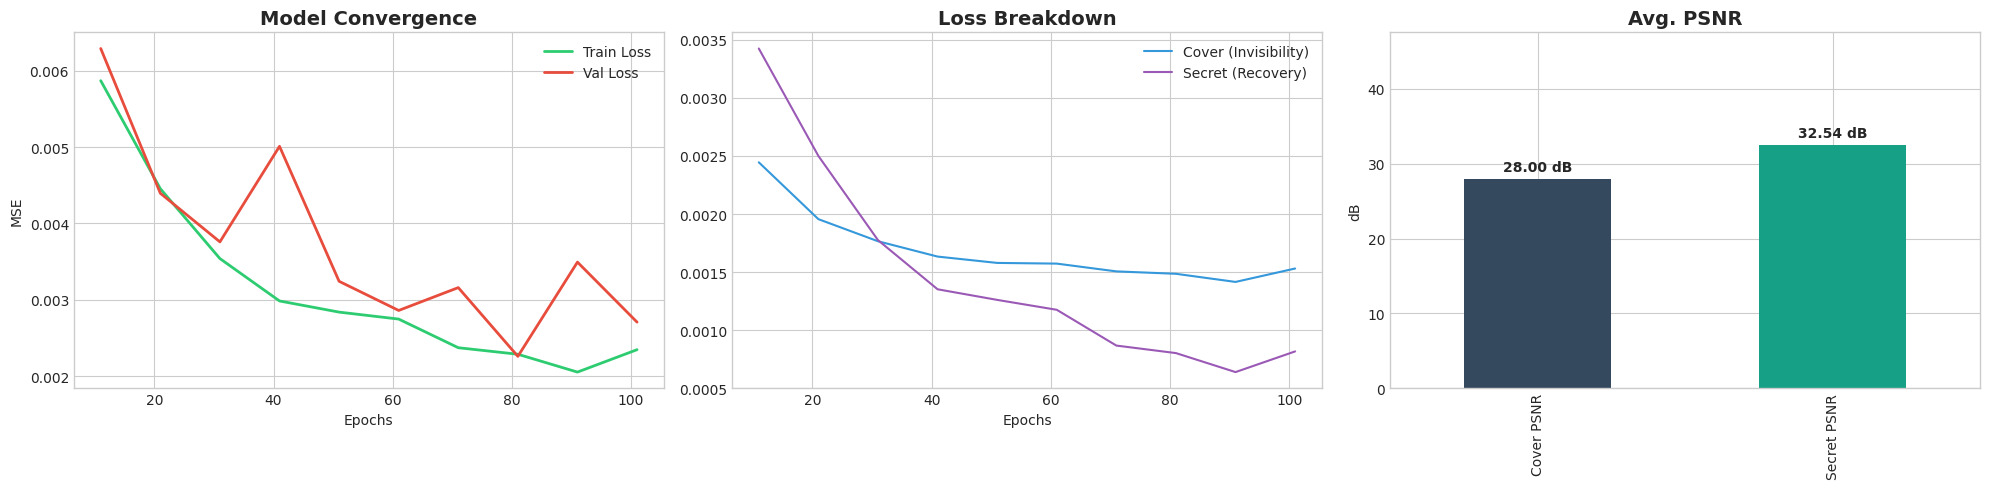

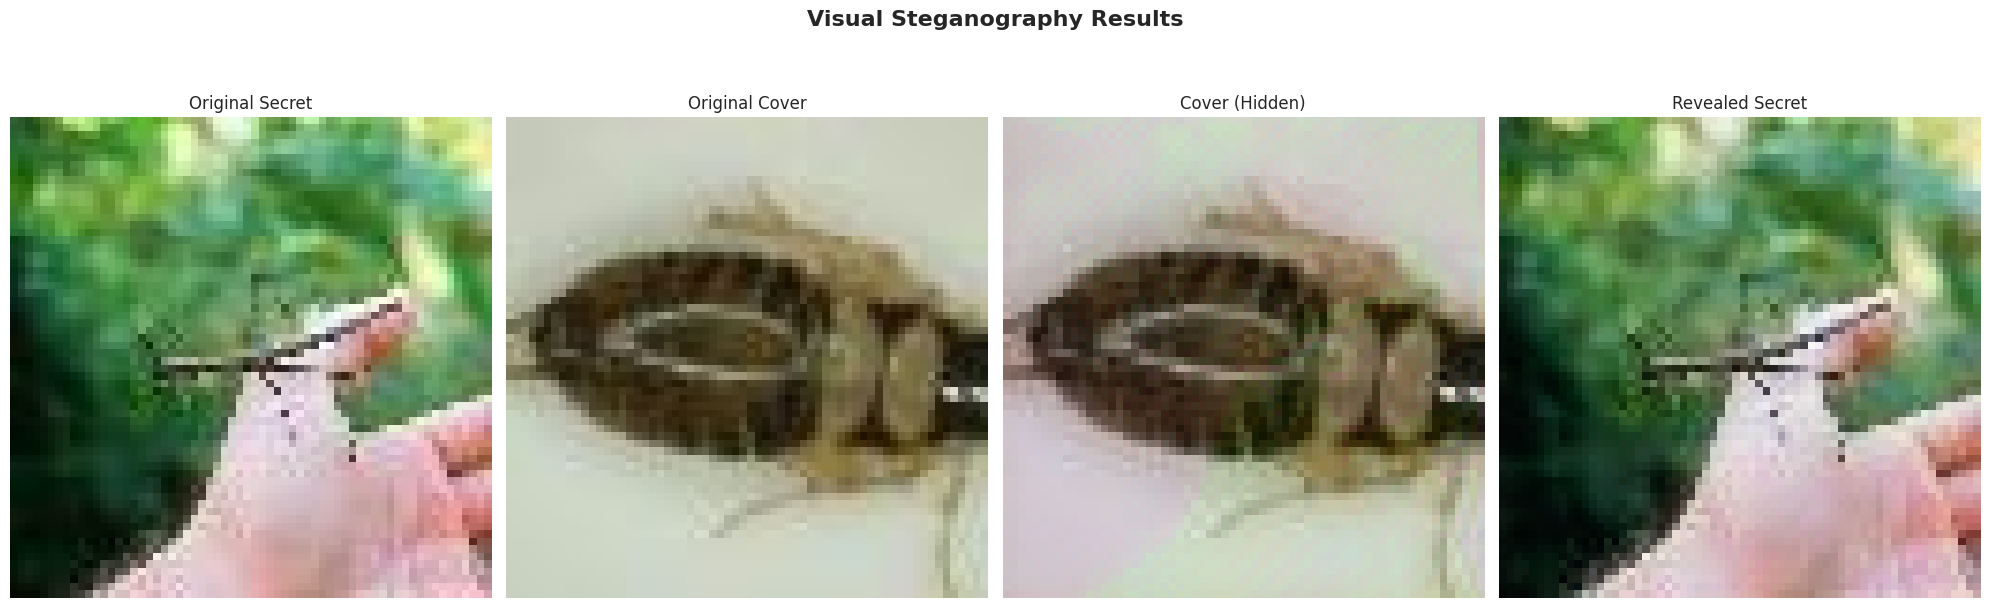

✅ Detailed metrics saved to: ./checkpoints/no_keras/final_evaluation_metrics.csv
✅ Average summary saved to:  ./checkpoints/no_keras/evaluation_summary.csv


In [23]:


final_weight_check()

# --- 1. Setup Accumulators ---
all_metrics = {
    "total_loss": [], "cover_loss": [], "secret_loss": [],
    "psnr_c": [], "ssim_c": [], "psnr_s": [], "ssim_s": [],
    "ber": [], "text_acc": []
}

# Assuming test_cover_np and test_secret_np are your full holdout arrays
num_samples = len(holdout_cover_np)
secret_text = "Hello World! \0"
codec = HuffmanCodec.from_data(secret_text)
modified_secret_np = []
for j in range(num_samples):
    modified_secret_np.append(lsb_embed_robust(
        secret_text, holdout_secret_np[j], codec))
modified_secret_np = np.array(modified_secret_np)
print(f"Evaluating {num_samples} samples...")

for i in range(num_samples):
    # Prepare single sample
    sc = to_scale(holdout_cover_np[i:i+1])
    ss = to_scale(modified_secret_np[i:i+1])

    # Inference
    p_out = prep_network(ss)
    h_out = hide_network(sc, p_out)
    r_out = reveal_network(h_out)

    # Calculate Losses
    t_loss, c_loss, s_loss = steganography_loss(sc, ss, h_out, r_out)
    rev_img = to_display(r_out)

    # --- THE FIX: Robust Text Recovery ---
    try:
        # If the NN noise flips an LSB, this throws an error. We catch it so the notebook survives.
        revealed_text = lsb_extract_robust(rev_img, codec)
    except Exception as e:
        revealed_text = ""
        print(
            f"Sample {i+1}: LSB decoding failed due to network noise. with error: {e}")

    text_acc = acc_txt(secret_text, revealed_text)
    all_metrics['text_acc'].append(text_acc)
    # Calculate Quality Metrics
    p_c = tf.image.psnr(sc, h_out, max_val=1.0)
    s_c = tf.image.ssim(sc, h_out, max_val=1.0)
    p_s = tf.image.psnr(ss, r_out, max_val=1.0)
    s_s = tf.image.ssim(ss, r_out, max_val=1.0)
    ber = calculate_ber(ss, r_out)

    # Append to lists (using .numpy() to get scalars)
    all_metrics["total_loss"].append(t_loss.numpy())
    all_metrics["cover_loss"].append(c_loss.numpy())
    all_metrics["secret_loss"].append(s_loss.numpy())
    all_metrics["psnr_c"].append(p_c.numpy()[0])
    all_metrics["ssim_c"].append(s_c.numpy()[0])
    all_metrics["psnr_s"].append(p_s.numpy()[0])
    all_metrics["ssim_s"].append(s_s.numpy()[0])
    all_metrics["ber"].append(ber)

# --- 2. Final Averaging ---
last_samples = [to_display(ss), to_display(
    sc), to_display(h_out), to_display(r_out)]
print("\n=== Final Evaluation Metrics ===")
print(f"Secret text accuracy: {np.mean(all_metrics['text_acc'])*100:.2f}%")
print(f"Revealed text: \"{revealed_text}\"")
plot_final_summary(df_history, all_metrics, last_samples)

df_final_metrics = pd.DataFrame(all_metrics)


# Save per-sample metrics (1000 rows)
metrics_path = os.path.join(checkpoint_dir, 'final_evaluation_metrics.csv')
df_final_metrics.to_csv(metrics_path, index_label='sample_id')

# Also save a 'Summary' file with just the averages
summary_stats = df_final_metrics.mean().to_frame().transpose()
summary_path = os.path.join(checkpoint_dir, 'evaluation_summary.csv')
summary_stats.to_csv(summary_path, index=False)

print(f"✅ Detailed metrics saved to: {metrics_path}")
print(f"✅ Average summary saved to:  {summary_path}")